In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


In [2]:
df=pd.read_csv('data/processed_data.csv')
df

,title,text,subject,date,label,text_length,title_length,word_count,punct_count,punct_density,capital_count,capital_density,numeric_count,avg_word_length
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,2893,79,495,121,0.041825,138,0.047701,110,5.844444
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,1898,69,305,39,0.020548,88,0.046365,4,6.222951
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,3597,90,580,148,0.041145,308,0.085627,99,6.201724
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,2774,78,444,118,0.042538,123,0.044340,75,6.247748
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,2346,70,420,40,0.017050,63,0.026854,0,5.585714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44684,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1,2821,61,466,71,0.025168,116,0.041120,23,6.053648
44685,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1,800,52,125,18,0.022500,39,0.048750,4,6.400000
44686,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1,1950,49,320,48,0.024615,54,0.027692,14,6.093750
44687,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1,1199,61,205,21,0.017515,55,0.045872,6,5.848780


In [3]:
df=df.drop('date', axis=1)
df

,title,text,subject,label,text_length,title_length,word_count,punct_count,punct_density,capital_count,capital_density,numeric_count,avg_word_length
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,0,2893,79,495,121,0.041825,138,0.047701,110,5.844444
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,0,1898,69,305,39,0.020548,88,0.046365,4,6.222951
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,0,3597,90,580,148,0.041145,308,0.085627,99,6.201724
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,0,2774,78,444,118,0.042538,123,0.044340,75,6.247748
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,0,2346,70,420,40,0.017050,63,0.026854,0,5.585714
...,...,...,...,...,...,...,...,...,...,...,...,...,...
44684,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,1,2821,61,466,71,0.025168,116,0.041120,23,6.053648
44685,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,1,800,52,125,18,0.022500,39,0.048750,4,6.400000
44686,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,1,1950,49,320,48,0.024615,54,0.027692,14,6.093750
44687,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,1,1199,61,205,21,0.017515,55,0.045872,6,5.848780


In [4]:
x = df.drop(columns=['label', 'subject'])
x.head()


,title,text,text_length,title_length,word_count,punct_count,punct_density,capital_count,capital_density,numeric_count,avg_word_length
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,2893,79,495,121,0.041825,138,0.047701,110,5.844444
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,1898,69,305,39,0.020548,88,0.046365,4,6.222951
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",3597,90,580,148,0.041145,308,0.085627,99,6.201724
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",2774,78,444,118,0.042538,123,0.044340,75,6.247748
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,2346,70,420,40,0.017050,63,0.026854,0,5.585714


In [5]:
y=df['label']
y.head()

0    0
1    0
2    0
3    0
4    0
Name: label, dtype: int64

In [6]:
num_features=x.select_dtypes(exclude='object').columns.to_list()
all_cat_features=x.select_dtypes(include='object').columns.to_list()

text_features=[col for col in all_cat_features if col in ['text','title']]
cat_features=[col for col in all_cat_features if col not in ['text', 'title']]

print(f"Text features: {text_features}")
print(f"Categorical features: {cat_features}")
print(f"Numerical features: {num_features}")

Text features: ['title', 'text']
Categorical features: []
Numerical features: ['text_length', 'title_length', 'word_count', 'punct_count', 'punct_density', 'capital_count', 'capital_density', 'numeric_count', 'avg_word_length']


In [7]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer

preprocessor= ColumnTransformer([
    ("TfidVectorizer", TfidfVectorizer(max_features=5000),'text'),
    ("OneHotEncoder", OneHotEncoder(drop='first'), cat_features),
    ("MinMaxScaler", MinMaxScaler(), num_features)
])

In [8]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape

((35751, 11), (8938, 11))

In [9]:
x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)

In [10]:
def evaluate_model(true, predicted):
    accuracy=accuracy_score(true, predicted)
    precision=precision_score(true, predicted)
    recall=recall_score(true, predicted)
    f1=f1_score(true, predicted)
    return accuracy, precision, recall, f1

In [13]:
models={
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=15),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=15, n_jobs=-1),
    "XGBClassifier": XGBClassifier(n_estimators=50, max_depth=8, n_jobs=-1, eval_metric='logloss'),
    "CatBoost": CatBoostClassifier(iterations=100, depth=8, verbose= False),
    "Adaboost": AdaBoostClassifier(n_estimators=50)
}

model_list=[]
accuracy_list=[]
f1_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(x_train, y_train)

    y_train_pred=model.predict(x_train)
    y_test_pred=model.predict(x_test)

    model_train_acc, model_train_prec, model_train_rec, model_train_f1= evaluate_model(y_train, y_train_pred)
    model_test_acc, model_test_prec, model_test_rec, model_test_f1=evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    f1_list.append(model_test_f1)

    print('Model perfrmance for training set')
    print("- Accuracy: {:.4f}".format(model_train_acc))
    print("- Precision: {:.4f}".format(model_train_prec))
    print("- Recall: {:.4f}".format(model_train_rec))
    print("- F1 Score: {:.4f}".format(model_train_f1))
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Accuracy: {:.4f}".format(model_test_acc))
    print("- Precision: {:.4f}".format(model_test_prec))
    print("- Recall: {:.4f}".format(model_test_rec))
    print("- F1 Score: {:.4f}".format(model_test_f1))
    accuracy_list.append(model_test_acc)
    
    print('='*35)

Logistic Regression
Model perfrmance for training set
- Accuracy: 0.9930
- Precision: 0.9897
- Recall: 0.9956
- F1 Score: 0.9927
----------------------------------
Model performance for Test set
- Accuracy: 0.9909
- Precision: 0.9875
- Recall: 0.9933
- F1 Score: 0.9904
Naive Bayes
Model perfrmance for training set
- Accuracy: 0.9370
- Precision: 0.9366
- Recall: 0.9307
- F1 Score: 0.9336
----------------------------------
Model performance for Test set
- Accuracy: 0.9344
- Precision: 0.9309
- Recall: 0.9295
- F1 Score: 0.9302
Decision Tree
Model perfrmance for training set
- Accuracy: 0.9990
- Precision: 0.9987
- Recall: 0.9992
- F1 Score: 0.9990
----------------------------------
Model performance for Test set
- Accuracy: 0.9963
- Precision: 0.9962
- Recall: 0.9960
- F1 Score: 0.9961
Random Forest
Model perfrmance for training set
- Accuracy: 0.9983
- Precision: 0.9969
- Recall: 0.9995
- F1 Score: 0.9982
----------------------------------
Model performance for Test set
- Accuracy: 0.9

In [16]:
results_df=pd.DataFrame({'Model':model_list, 'accuracy': accuracy_list, 'F1 score': f1_list}).sort_values(by='F1 score', ascending=False)
results_df

,Model,accuracy,F1 score
5,CatBoost,0.997203,0.997025
4,XGBClassifier,0.997203,0.997023
2,Decision Tree,0.996308,0.996071
6,Adaboost,0.995860,0.995597
3,Random Forest,0.993063,0.992626
0,Logistic Regression,0.990938,0.990386
1,Naive Bayes,0.934437,0.930188


Text(0.5, 1.0, 'Confusion matrix')

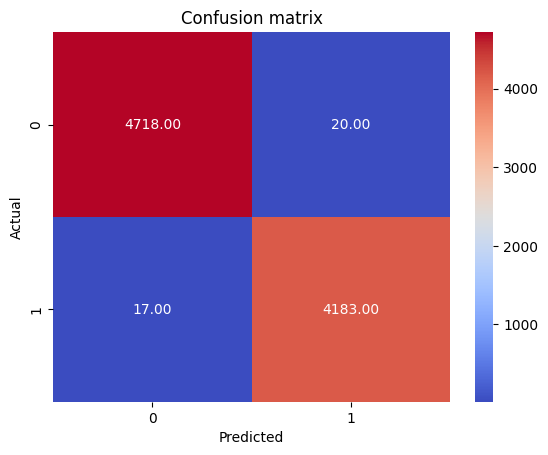

In [19]:
cm=confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='.2f', cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix')

In [21]:
classification_report(y_test, y_test_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00      4738\n           1       1.00      1.00      1.00      4200\n\n    accuracy                           1.00      8938\n   macro avg       1.00      1.00      1.00      8938\nweighted avg       1.00      1.00      1.00      8938\n'

In [22]:
error_df=pd.DataFrame({'Actual':y_test, 'Predicted':y_test_pred})
error_df[error_df['Actual']!=error_df['Predicted']].head()

,Actual,Predicted
38312,1,0
29225,1,0
10253,0,1
34893,1,0
16366,0,1
